# Lesson 15 Activity: Data Wrangling

## Learning Objectives

This activity will help you to:

1. Merge and aggregate data from multiple sources
2. Apply groupby operations to summarize data
3. Calculate meaningful statistics from aggregated data
4. Visualize aggregated results

## Setup

Import the required libraries.

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exercise 1: Merge Data and Calculate Monthly Sales

**Tasks**:

1. Merge `df_sales` and `df_dates` on the `transaction_id` column. Store the result in a dataframe called `df_transactions`.

2. Extract the month from the `sale_date` column and add it as a new column called `month` in `df_transactions`.

3. Calculate the total sales per month using groupby and sum. Store the result in a dataframe called `monthly_sales`.

4. Create a bar chart showing the total sales for each month. Include appropriate labels and title.

**Hints**:

- To merge two dataframes, use `pd.merge()` or the `.merge()` method. You can specify the column to join on with the `on` parameter.
  - Example: `df_merged = pd.merge(df1, df2, on='key_column')`
  - Or: `df_merged = df1.merge(df2, on='key_column')`

- To extract the month from a datetime column, use the `.dt.month` accessor.
  - Example: `df['month'] = df['date_column'].dt.month`

- To group by a column and calculate the sum, use `.groupby()` followed by `.sum()`.
  - Example: `grouped_df = df.groupby('group_column')['value_column'].sum()`
  - You can also use `.reset_index()` to convert the result back to a regular dataframe.

In [141]:
df_sales = pd.read_csv('sale_amounts.csv')
df_dates = pd.read_csv('sales_by_date.csv')

In [142]:
# Your code here

df_transactions = pd.merge(df_sales, df_dates, on='transaction_id')
print(df_transactions.describe().to_string())
print(df_transactions.info())
print(df_transactions.head())
df_transactions['sale_date'] = pd.to_datetime(df_transactions['sale_date'])
df_transactions['month'] = df_transactions['sale_date'].dt.month
monthly_sales_df = df_transactions.groupby('month')['sale_amount'].sum()
monthly_sales_df = monthly_sales_df.reset_index()
print(monthly_sales_df.describe().to_string())
print(monthly_sales_df.info())
print(monthly_sales_df.head(12))


       sale_amount
count   360.000000
mean    250.151694
std     143.052441
min      12.480000
25%     127.152500
50%     260.415000
75%     367.285000
max     495.130000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  360 non-null    object 
 1   sale_amount     360 non-null    float64
 2   sale_date       360 non-null    object 
dtypes: float64(1), object(2)
memory usage: 8.6+ KB
None
  transaction_id  sale_amount   sale_date
0        TXN0001       193.52  2024-08-01
1        TXN0002       475.85  2024-09-07
2        TXN0003       368.68  2024-08-25
3        TXN0004       303.34  2024-08-10
4        TXN0005        86.45  2024-02-15
           month  sale_amount
count  12.000000    12.000000
mean    6.500000  7504.550833
std     3.605551   822.333477
min     1.000000  6506.980000
25%     3.750000  6832.870000
50%     6.5

Text(0, 0.5, 'Total Sales Amount ($)')

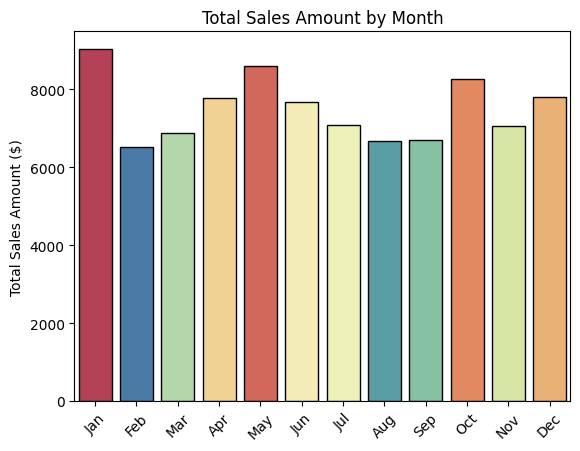

In [143]:
dbr = sns.color_palette('Spectral', n_colors=12)
rank = monthly_sales_df['sale_amount'].argsort().argsort()
sns.barplot(data=monthly_sales_df, x='month', y='sale_amount', hue='month', palette=list(np.array(dbr[::-1])[rank]), edgecolor='black', legend=False)
plt.title('Total Sales Amount by Month')
plt.xlabel('')
plt.xticks(rotation=45, ticks=range(0,12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Total Sales Amount ($)')


## Exercise 2: Analyze Missing Data Patterns

Load the California Housing dataset with missing values and investigate whether the pattern of missing data in the `HouseAge` feature is related to the `Population` feature.

**Background**: 
Sometimes data is not missing completely at random. In real-world scenarios, certain values might be more likely to be missing based on other features in the dataset. This is called Missing Not At Random (MNAR). Understanding these patterns is important for choosing appropriate imputation strategies.

**Tasks**:

1. Load the dataset from `salted_housing_data.csv` and examine the first few rows.

2. Create a new boolean column called `HouseAge_Missing` that indicates whether `HouseAge` is missing (True) or not (False).

3. Use `pd.qcut()` to bin the `Population` feature into 4 quartiles. Store the result in a new column called `Population_Quartile`. Use labels like `['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']`.

4. Calculate the percentage of missing `HouseAge` values for each population quartile. Use `groupby()` to group by `Population_Quartile` and calculate:
   - The count of missing values (sum of `HouseAge_Missing`)
   - The total count in each quartile
   - The percentage missing

5. Create a bar chart showing the percentage of missing `HouseAge` values by population quartile. Add value labels on top of each bar.

6. Based on your analysis, answer: Is `HouseAge` more likely to be missing in certain population groups? What does this suggest about the missing data mechanism?

**Hints**:

- To check for missing values, use `.isnull()` or `.isna()`.
  - Example: `df['HouseAge_Missing'] = df['HouseAge'].isnull()`

- To create quartile bins, use `pd.qcut()` with `q=4`.
  - Example: `df['quartile'] = pd.qcut(df['column'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])`

- To calculate percentage missing by group:
  - Group by the quartile column
  - Use `.agg()` with multiple functions: `{'HouseAge_Missing': ['sum', 'count']}`
  - Calculate percentage: `(sum / count) * 100`

- Missing data mechanisms:
  - **MCAR** (Missing Completely At Random): No relationship between missingness and any variable
  - **MAR** (Missing At Random): Missingness depends on observed variables
  - **MNAR** (Missing Not At Random): Missingness depends on the missing value itself or unobserved variables

In [144]:
housing_df = pd.read_csv('https://gperdrizet.github.io/FSA_devops/assets/data/unit2/salted_housing_data.csv')

In [145]:
# Your code here
print(housing_df.describe().to_string())
print(housing_df.info())
print(housing_df.head().to_string())

             MedInc      HouseAge      AveRooms     AveBedrms    Population      AveOccup      Latitude     Longitude   MedHouseVal
count  19094.000000  20451.000000  19141.000000  17282.000000  17075.000000  17596.000000  17938.000000  16631.000000  19553.000000
mean       3.869517     28.638551      5.426283      1.096446   1425.504890      3.093417     35.640733   -119.574790      2.070947
std        1.906203     12.590877      2.484484      0.459792   1137.027186     11.239466      2.138558      2.002598      1.154240
min        0.499900      1.000000      0.846154      0.333333      3.000000      0.692308     32.540000   -124.300000      0.149990
25%        2.560475     18.000000      4.442100      1.005799    788.000000      2.433650     33.930000   -121.800000      1.201000
50%        3.529900     29.000000      5.226872      1.048676   1166.000000      2.819087     34.260000   -118.510000      1.800000
75%        4.744225     37.000000      6.049080      1.099046   1728.000000 

## Exercise 3: Apply Imputation to Missing Data

Now that you've analyzed the missing data pattern, select and apply an appropriate imputation method to fill in the missing `HouseAge` values.

**Background**:
Based on your findings from Exercise 2, you discovered that `HouseAge` is more likely to be missing in areas with lower population (MNAR pattern). This information should guide your choice of imputation method. Advanced methods like KNN or Iterative Imputation can leverage relationships between features, which is particularly useful when data is not missing completely at random.

**Tasks**:

1. Choose an imputation method. Consider:
   - Simple methods: Mean or Median imputation
   - Advanced methods: KNN Imputation or Iterative Imputation
   - Justify your choice based on the missing data pattern you discovered
2. Apply your chosen imputation method to fill the missing `HouseAge` values. Store the result in a new column called `HouseAge_imputed`.

3. Compare the distribution of the original `HouseAge` (non-missing values only) with the imputed values:
   - Create a histogram showing both distributions
   - Calculate summary statistics (mean, median, std) for both

4. Evaluate your imputation:
   - Does the imputed distribution look reasonable compared to the original?
   - Are there any obvious problems or artifacts introduced by the imputation?
   - Would a different method have been better? Why or why not?

In [146]:
# Your code here
